# Импорты и вспомогательные функции

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from helpers.feature_extraction_expanded import *
from helpers.classic_ml_models import *
from helpers.clusterization_features_extraction import *

Failed to import duecredit due to No module named 'duecredit'


In [2]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [3]:
# У реализации sklift не получается связка с текущей версией numpy, которую мы поставили для работы causalml на UpliftTree, поэтому напишем собственные графики

def get_uplift_percentile_table(y_true, uplift_preds, treatment, bins=10):
    y_true = np.asarray(y_true).reshape(-1)
    uplift_preds = np.asarray(uplift_preds).reshape(-1)
    treatment = np.asarray(treatment).reshape(-1)

    df = uplift_by_percentile(
        y_true=y_true,
        uplift=uplift_preds,
        treatment=treatment,
        strategy='overall',
        bins=bins,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index()

    if 'index' in df.columns:
        df = df.rename(columns={'index': 'percentile'})

    # На всякий случай приводим к числам
    numeric_cols = [
        'n_treatment',
        'n_control',
        'response_rate_treatment',
        'response_rate_control',
        'uplift'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Стандартные ошибки для error bars
    p_t = df['response_rate_treatment'].to_numpy()
    p_c = df['response_rate_control'].to_numpy()
    n_t = df['n_treatment'].to_numpy()
    n_c = df['n_control'].to_numpy()

    se_t = np.sqrt(np.where(n_t > 0, p_t * (1 - p_t) / n_t, np.nan))
    se_c = np.sqrt(np.where(n_c > 0, p_c * (1 - p_c) / n_c, np.nan))
    se_u = np.sqrt(np.nan_to_num(se_t, nan=0.0) ** 2 + np.nan_to_num(se_c, nan=0.0) ** 2)

    df['se_treatment'] = se_t
    df['se_control'] = se_c
    df['se_uplift'] = se_u

    return df

def plot_percentile_grid(preds_dict, y_true, treatment, split_name, bins=10):
    model_names = list(preds_dict.keys())

    fig = plt.figure(figsize=(18, 14))
    outer = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)

    for i, model_name in enumerate(model_names):
        row, col = divmod(i, 2)

        inner = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[1, 1.05],
            hspace=0.18
        )

        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        preds = preds_dict[model_name]
        df = get_uplift_percentile_table(
            y_true=y_true,
            uplift_preds=preds,
            treatment=treatment,
            bins=bins
        )

        wau = weighted_average_uplift(y_true, preds, treatment)

        x = np.arange(len(df))
        width = 0.36

        # Верхний график: uplift by percentile
        ax_top.bar(
            x,
            df['uplift'],
            yerr=df['se_uplift'],
            capsize=2,
            color='red',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='uplift'
        )
        ax_top.axhline(0, color='black', linewidth=1)

        ax_top.set_title(
            f'{model_name}\nUplift by percentile\nweighted average uplift = {wau:.4f}',
            fontsize=11,
            fontweight='bold'
        )
        ax_top.set_ylabel('Uplift = treatment response rate - control response rate', fontsize=10)
        ax_top.legend(loc='upper right', fontsize=9, frameon=True)
        ax_top.grid(axis='y', linestyle='--', alpha=0.35)
        ax_top.tick_params(axis='x', labelbottom=False)

        # Нижний график: response rate by percentile
        ax_bottom.bar(
            x - width / 2,
            df['response_rate_treatment'],
            width=width,
            yerr=df['se_treatment'],
            capsize=2,
            color='forestgreen',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='treatment\nresponse rate'
        )

        ax_bottom.bar(
            x + width / 2,
            df['response_rate_control'],
            width=width,
            yerr=df['se_control'],
            capsize=2,
            color='orange',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='control\nresponse rate'
        )

        ax_bottom.set_title('Response rate by percentile', fontsize=11, fontweight='bold')
        ax_bottom.set_ylabel('response rate', fontsize=10)
        ax_bottom.set_xlabel('Percentile', fontsize=10)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(df['percentile'], rotation=35)
        ax_bottom.legend(loc='upper right', fontsize=9, frameon=True)
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.35)

    # fig.suptitle(f'Uplift by percentile | {split_name}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])

    return fig

In [4]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift_at_10_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift_at_20_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift_at_30_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift_at_50_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

# Подготовка MLflow

In [5]:
os.environ["MLFLOW_TRACKING_URI"] = "http://localhost:5000"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"

In [6]:
import mlflow
import mlflow.catboost
import mlflow.sklearn

# Фиксация seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Настройка MLflow
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000"))
mlflow.set_experiment("X-Learner CatBoost")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow tracking URI: http://localhost:5000


# Подготовка датасета

In [7]:
dataset = fetch_x5()
data = dataset.data

In [8]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [9]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


In [10]:
current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

# Обучение и логирование X-learner

In [11]:
with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"MLflow run ID: {run_id}")

    mlflow.log_params({f"outcome_model_{k}": v for k, v in XL_OUTCOME_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"effect_model_{k}": v for k, v in XL_EFFECT_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"propensity_model_{k}": v for k, v in XL_PROPENSITY_CATBOOST_PARAMS.items()})

    # Обучение
    x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
    x_learner_full.outcome_learner = CalibratedClassifierCV(x_learner_full.outcome_learner, method='isotonic', cv=3)
    x_learner_full.propensity_learner = CalibratedClassifierCV(x_learner_full.propensity_learner, method='isotonic', cv=3)
    x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)

    # Делаем предикты
    preds_x_test = x_learner_full.predict(x_test_holdout_clust)
    test_holdout_preds = {'X-Learner (CatBoost)': preds_x_test}

    # Сохраяем метрики
    metrics = calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)
    mlflow.log_metrics(metrics)

    # Сохраняем модели
    mlflow.catboost.log_model(x_learner_full.model_tau_0, "model_tau_0", registered_model_name="model_tau_0")
    mlflow.catboost.log_model(x_learner_full.model_tau_1, "model_tau_1", registered_model_name="model_tau_1")
    mlflow.sklearn.log_model(x_learner_full.model_propensity, "model_propensity", registered_model_name="model_propensity")

MLflow run ID: 0a2a91d05c3b4835906ee11cc656bbd9
0:	learn: 0.6833568	total: 178ms	remaining: 25.9s
100:	learn: 0.5575485	total: 4.07s	remaining: 1.85s
146:	learn: 0.5550922	total: 5.57s	remaining: 0us
0:	learn: 0.6837294	total: 32.5ms	remaining: 4.74s
100:	learn: 0.5585514	total: 3.41s	remaining: 1.55s
146:	learn: 0.5561439	total: 4.91s	remaining: 0us
0:	learn: 0.6836681	total: 34.9ms	remaining: 5.1s
100:	learn: 0.5573746	total: 3.94s	remaining: 1.79s
146:	learn: 0.5549251	total: 5.66s	remaining: 0us
0:	learn: 0.6827809	total: 37.3ms	remaining: 5.44s
100:	learn: 0.5492640	total: 3.7s	remaining: 1.69s
146:	learn: 0.5464749	total: 5.37s	remaining: 0us
0:	learn: 0.6832013	total: 32.1ms	remaining: 4.69s
100:	learn: 0.5455101	total: 3.48s	remaining: 1.59s
146:	learn: 0.5426694	total: 5.06s	remaining: 0us
0:	learn: 0.6833133	total: 34.7ms	remaining: 5.07s
100:	learn: 0.5475150	total: 3.71s	remaining: 1.69s
146:	learn: 0.5443704	total: 5.55s	remaining: 0us
0:	learn: 0.4362541	total: 24.2ms	rem

Registered model 'model_tau_0' already exists. Creating a new version of this model...
2026/05/31 16:31:48 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_0, version 2
Created version '2' of model 'model_tau_0'.
Registered model 'model_tau_1' already exists. Creating a new version of this model...
2026/05/31 16:31:51 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_1, version 2
Created version '2' of model 'model_tau_1'.
Registered model 'model_propensity' already exists. Creating a new version of this model...
2026/05/31 16:31:54 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_propensity, version 2
Created version '2' of model 'model_propensity'.


In [12]:
test_results_df = pd.DataFrame([{'Model': 'X-Learner (CatBoost)', 'Split': 'test_holdout', **metrics}])
display(test_results_df)

,Model,Split,AUUC,Qini,WAU,Uplift_at_10_perc,Uplift_at_20_perc,Uplift_at_30_perc,Uplift_at_50_perc
0,X-Learner (CatBoost),test_holdout,0.022733,0.014864,0.034174,0.119,0.080524,0.064338,0.043951


# Артефакты (графики)

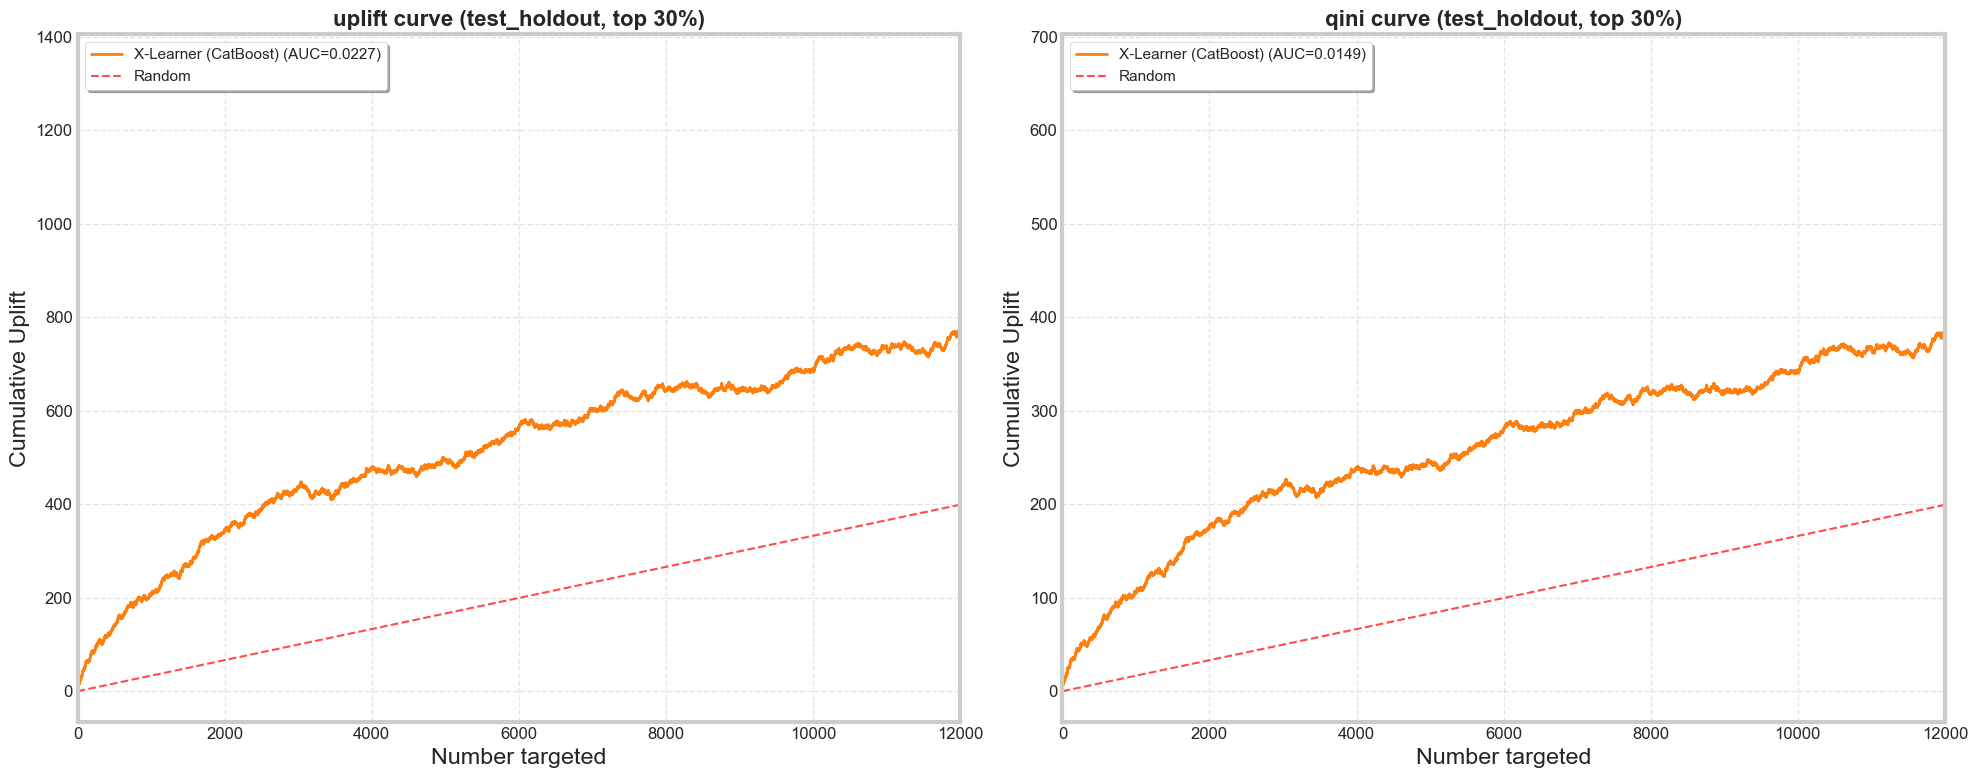

In [13]:
with mlflow.start_run(run_id=run_id):
    top_k_percent = 0.3
    
    model_colors = {
        "X-Learner (CatBoost)": "#ff7f0e"
    }
    
    model_styles = {
        "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0}
    }
    
    split_specs = {
        "test_holdout": {
            "y": y_test_holdout,
            "t": t_test_holdout,
            "preds_dict": test_holdout_preds
        }
    }
    
    for split_name, split_data in split_specs.items():
        y_split = split_data["y"]
        t_split = split_data["t"]
        preds_dict = split_data["preds_dict"]
    
        max_x = int(len(y_split) * top_k_percent)
    
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
        for model_name, preds in preds_dict.items():
            style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
            color = model_colors.get(model_name, "gray")
    
            plot_uplift_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[0],
                color=color,
                perfect=False,
                **style
            )
    
            plot_qini_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[1],
                color=color,
                perfect=False,
                **style
            )
    
        axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
        axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
    
        for ax in axes:
            ax.set_xlim(0, max_x)
            ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
            ax.grid(True, which='both', linestyle='--', alpha=0.5)
            ax.tick_params(axis='both', which='major', labelsize=12)
    
        plt.tight_layout()

        mlflow.log_figure(fig, "uplift_curves.png")
        plt.show()

In [14]:
percentile_frames = []

for model_name, preds in test_holdout_preds.items():
    df_test_pct = uplift_by_percentile(
        y_true=y_test_holdout,
        uplift=preds,
        treatment=t_test_holdout,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_test_pct['Model'] = model_name
    df_test_pct['Split'] = 'test_holdout'
    percentile_frames.append(df_test_pct)

all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

for col in ['n_treatment', 'n_control']:
    all_percentiles_df[col] = all_percentiles_df[col].round().astype('Int64')

all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

In [15]:
split_name = 'test_holdout'

split_percentiles_df = all_percentiles_df[all_percentiles_df['Split'] == split_name].copy()

pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

display_df = pivot_uplift.copy()
display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

for model in model_columns:
    display_df[model] = (
        pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
        + '\n' +
        'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
    )

gmap_df = pivot_uplift[model_columns].copy()
gmap_df.index = display_df.index

styled_df = (
    display_df.style
    .background_gradient(
        cmap='RdYlGn',
        subset=model_columns,
        gmap=gmap_df,
        vmin=-0.05,
        vmax=0.05,
        axis=None
    )
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('background-color', '#ff7f0e'),
                ('border', '1px solid black')
            ]
        }
    ])
    .hide(axis='index')
)

display(styled_df)

Перцентиль (бакет),X-Learner (CatBoost)
0-10,"+11.92% n=4001, t=2001, c=2000"
10-20,"+4.22% n=4001, t=1958, c=2043"
20-30,"+3.12% n=4001, t=2023, c=1978"
30-40,"+2.57% n=4001, t=2058, c=1943"
40-50,"-0.14% n=4001, t=2034, c=1967"
50-60,"+4.47% n=4001, t=1986, c=2015"
60-70,"+3.21% n=4001, t=1988, c=2013"
70-80,"+0.95% n=4001, t=2055, c=1946"
80-90,"+3.53% n=4000, t=1937, c=2063"
90-100,"+0.44% n=4000, t=1956, c=2044"


In [16]:
with mlflow.start_run(run_id=run_id):
    temp_html_path = "bucket_uplift.html"
    styled_df.to_html(temp_html_path)
    
    mlflow.log_artifact(temp_html_path, "bucket_uplift")

    os.remove(temp_html_path)

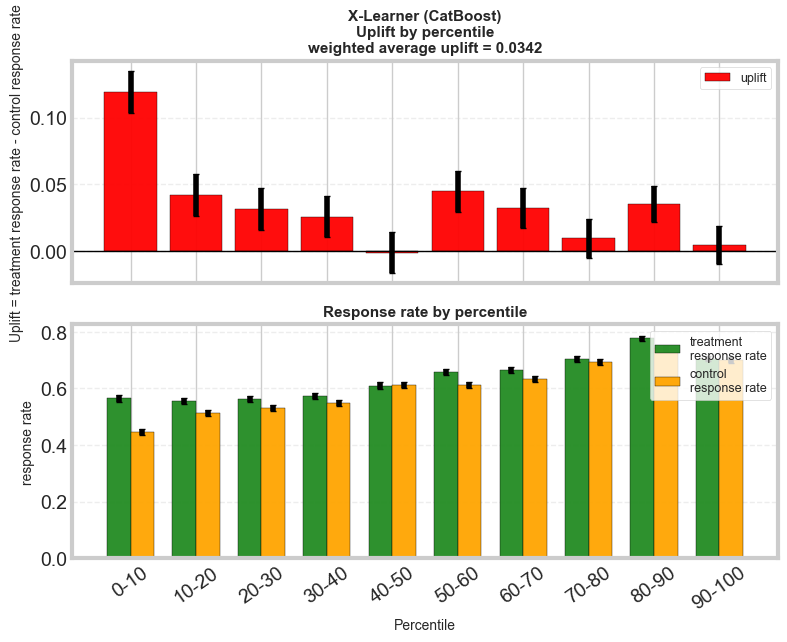

In [17]:
with mlflow.start_run(run_id=run_id):
    fig = plot_percentile_grid(
        preds_dict=test_holdout_preds,
        y_true=y_test_holdout,
        treatment=t_test_holdout,
        split_name='test_holdout',
        bins=10
    )
    mlflow.log_figure(fig, "uplift_by_percentile.png")
    plt.show()

## Анализ устойчивости модели
Внесем контролируемый шум в числовые признаки тестового набора данных, чтобы проверить стабильность работы X-Learner на зашумленных данных.

In [18]:
def add_gaussian_noise(df, num_cols, noise_level=0.05):
    df_noisy = df.copy()
    for col in num_cols:
        std = df[col].std()
        if pd.isna(std) or std == 0:
            std = 1.0
        noise = np.random.normal(0, noise_level * std, size=len(df))
        df_noisy[col] = df_noisy[col] + noise
    return df_noisy

def add_dropout_noise(df, num_cols, dropout_rate=0.05):
    df_noisy = df.copy()
    for col in num_cols:
        mask = np.random.rand(len(df)) < dropout_rate
        df_noisy.loc[mask, col] = 0.0
    return df_noisy

def evaluate_robustness(model, x_test, y_test, t_test, num_cols, noise_levels, noise_type="gaussian"):
    results = []
    for level in noise_levels:
        if level == 0.0:
            x_perturbed = x_test.copy()
        else:
            if noise_type == "gaussian":
                x_perturbed = add_gaussian_noise(x_test, num_cols, noise_level=level)
            elif noise_type == "dropout":
                x_perturbed = add_dropout_noise(x_test, num_cols, dropout_rate=level)
        
        # Инференс на зашумленных признаках
        preds = model.predict(x_perturbed)
        
        # Расчет метрик
        auuc = uplift_auc_score(y_test, preds, t_test)
        qini = qini_auc_score(y_test, preds, t_test)
        u10 = uplift_at_k(y_test, preds, t_test, strategy='overall', k=0.1)
        
        results.append({
            "noise_level": level,
            "AUUC": auuc,
            "Qini": qini,
            "Uplift@10%": u10
        })
    return pd.DataFrame(results)

Проверка устойчивости модели


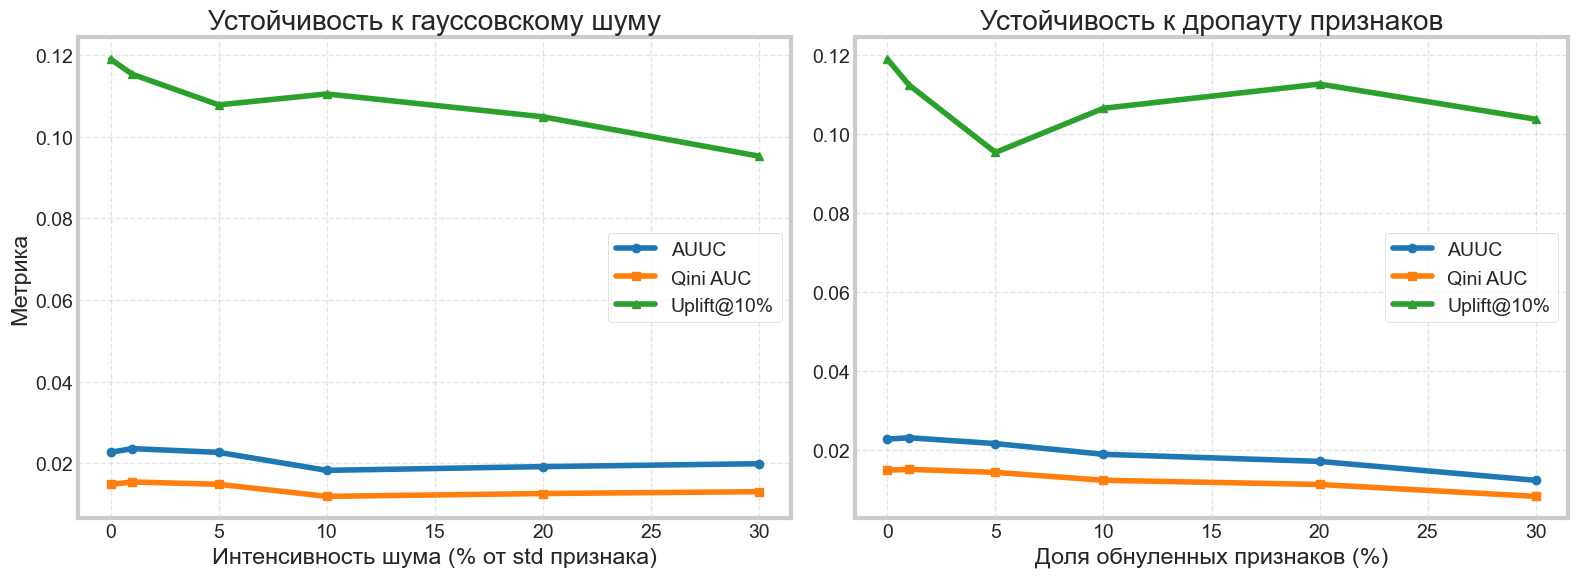

In [19]:
with mlflow.start_run(run_id=run_id):
    print("Проверка устойчивости модели")
    num_cols_to_noise = [c for c in num_cols_full if c not in ['cluster_id', 'first_transaction_quarter']]
    
    noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30]
    
    # Оценка устойчивости к двум видам шума
    gauss_results = evaluate_robustness(
        model=x_learner_full,
        x_test=x_test_holdout_clust,
        y_test=y_test_holdout,
        t_test=t_test_holdout,
        num_cols=num_cols_to_noise,
        noise_levels=noise_levels,
        noise_type="gaussian"
    )
    
    dropout_results = evaluate_robustness(
        model=x_learner_full,
        x_test=x_test_holdout_clust,
        y_test=y_test_holdout,
        t_test=t_test_holdout,
        num_cols=num_cols_to_noise,
        noise_levels=noise_levels,
        noise_type="dropout"
    )
    
    # Сохранение и логирование
    gauss_csv_path = "robustness_gaussian_results.csv"
    dropout_csv_path = "robustness_dropout_results.csv"
    
    gauss_results.to_csv(gauss_csv_path, index=False)
    dropout_results.to_csv(dropout_csv_path, index=False)
    
    mlflow.log_artifact(gauss_csv_path, "robustness_metrics")
    mlflow.log_artifact(dropout_csv_path, "robustness_metrics")
    
    if os.path.exists(gauss_csv_path):
        os.remove(gauss_csv_path)
    if os.path.exists(dropout_csv_path):
        os.remove(dropout_csv_path)
        
    # Построение графиков деградации качества
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # График гауссовского шума
    axes[0].plot(gauss_results["noise_level"] * 100, gauss_results["AUUC"], marker='o', label="AUUC", color='#1f77b4')
    axes[0].plot(gauss_results["noise_level"] * 100, gauss_results["Qini"], marker='s', label="Qini AUC", color='#ff7f0e')
    axes[0].plot(gauss_results["noise_level"] * 100, gauss_results["Uplift@10%"], marker='^', label="Uplift@10%", color='#2ca02c')
    axes[0].set_title("Устойчивость к гауссовскому шуму")
    axes[0].set_xlabel("Интенсивность шума (% от std признака)")
    axes[0].set_ylabel("Метрика")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend()
    
    axes[1].plot(dropout_results["noise_level"] * 100, dropout_results["AUUC"], marker='o', label="AUUC", color='#1f77b4')
    axes[1].plot(dropout_results["noise_level"] * 100, dropout_results["Qini"], marker='s', label="Qini AUC", color='#ff7f0e')
    axes[1].plot(dropout_results["noise_level"] * 100, dropout_results["Uplift@10%"], marker='^', label="Uplift@10%", color='#2ca02c')
    axes[1].set_title("Устойчивость к дропауту признаков")
    axes[1].set_xlabel("Доля обнуленных признаков (%)")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend()
    
    plt.tight_layout()
    
    mlflow.log_figure(fig, "robustness_metrics/metrics_decay_curves.png")
    plt.show()

### Вывод по анализу устойчивости

Стресс-тестирование модели X-Learner на отложенной выборке подтвердило высокую устойчивость алгоритма к искажениям во входных данных:

1. Гауссовский шум: При зашумлении числовых признаков вплоть до 30% от их стандартного отклонения интегральные метрики  остаются стабильными, демонстрируя плавное, контролируемое снижение.
2. Дропаут признаков: При случайной утере до 30% признаков качество ранжирования снижается постепенно, сохраняя выраженный положительный аплифт-сигнал.

# Добавление тега PRD

In [20]:
client = mlflow.tracking.MlflowClient()

client.set_registered_model_tag(name="model_tau_0", key="stage", value="PRD")
client.set_registered_model_tag(name="model_tau_1", key="stage", value="PRD")
client.set_registered_model_tag(name="model_propensity", key="stage", value="PRD")